# How the detectors compare on simulated sessions

Every detector in `ripple_detection`, at its defaults, on sessions from `simulate_session`: pink (1/f) noise, ripples of known time, duration (40-120 ms) and frequency (150-250 Hz) sized by `ripple_snr` (their peak after ripple-band filtering, in units of the filtered background's SD), channels that share half their noise, a stratum radiatum channel carrying a sharp wave under each ripple for the Long detector, and a population of Poisson units that burst with each ripple for the Carey and HSE detectors.

The sweep is `simulation_study.py` beside this notebook (`uv run python examples/simulation_study.py`, about ten minutes); it writes `simulation_study_results.csv`, which this notebook reads. Conditions:

- **ripples**: 40 ripples in 120 s, `ripple_snr` 1.5 to 6, 1, 4 or 8 channels, three seeds, 100 units.
- **noise only**: the same sessions with no ripples, for the false-positive rate.
- **sparse population**: 20 units instead of 100, `ripple_snr` 4, for the spike detectors.
- **artifacts**: 40 ripples at `ripple_snr` 3 plus 20 common-mode broadband bursts.

An event counts as a hit when it overlaps the ripple's window (centre ± half the duration, where the envelope is at 1 percent of its peak). **Recall** is the fraction of ripples hit; **precision** the fraction of events that hit a ripple; **onset error** the median of event start minus window start over hit ripples, so negative is early.

What this can and cannot show is in the last section.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ripple_detection as rd

results = pd.read_csv(Path("simulation_study_results.csv") if Path("simulation_study_results.csv").exists() else Path("examples/simulation_study_results.csv"))
SHORT = {
    "Kay_ripple_detector": "Kay", "Karlsson_ripple_detector": "Karlsson", "Roumis_ripple_detector": "Roumis",
    "Shvartsman_ripple_detector": "Shvartsman", "Yu_ripple_detector": "Yu", "Zugaro_ripple_detector": "Zugaro",
    "Long_sharp_wave_ripple_detector": "Long", "Carey_candidate_detector": "Carey", "multiunit_HSE_detector": "HSE",
}
ORDER = list(SHORT.values())
results["detector"] = results.detector.map(SHORT)
results["error"] = results.error.fillna("")
print(f"{len(results)} rows; rows where a detector raised: {results.error.ne('').sum()}")
results[results.error.ne("")][["condition", "n_channels", "detector", "error"]].drop_duplicates(["detector", "error"])

540 rows; rows where a detector raised: 18


,condition,n_channels,detector,error
3,ripples,1,Shvartsman,minimum_participating_channels is 2 but filter...


## Recall and precision against ripple size

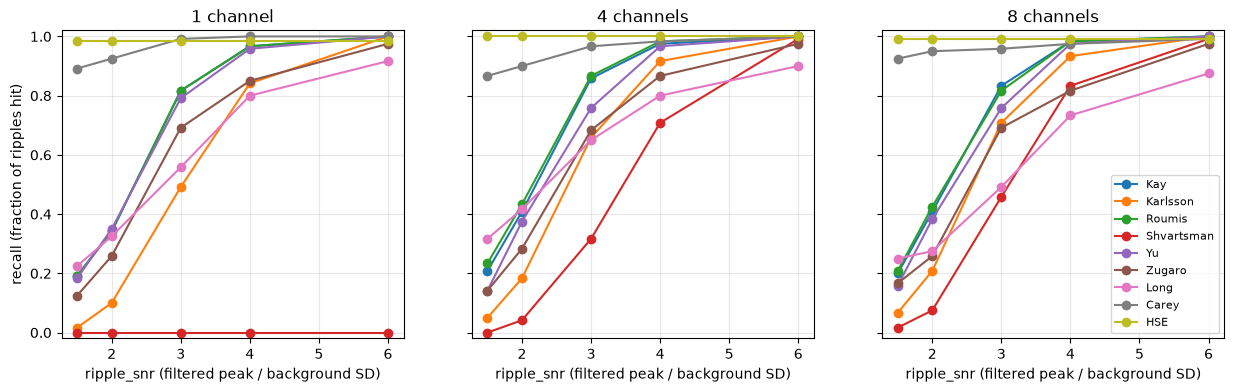

In [2]:
ripples = results[results.condition == "ripples"]

def curves(metric, ylabel):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, n_channels in zip(axes, sorted(ripples.n_channels.unique())):
        table = (
            ripples[ripples.n_channels == n_channels]
            .pivot_table(index="ripple_snr", columns="detector", values=metric, aggfunc="mean")
            .reindex(columns=ORDER)
        )
        for detector in ORDER:
            ax.plot(table.index, table[detector], marker="o", label=detector)
        ax.set_title(f"{n_channels} channel{'s' if n_channels > 1 else ''}")
        ax.set_xlabel("ripple_snr (filtered peak / background SD)")
        ax.set_ylim(-0.02, 1.02)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(ylabel)
    axes[-1].legend(loc="lower right", fontsize=8)
    return fig

curves("recall", "recall (fraction of ripples hit)");

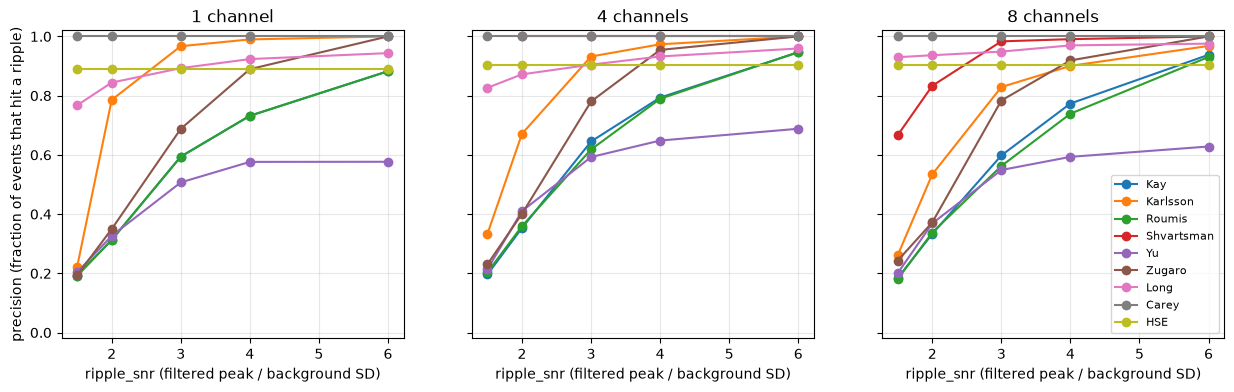

In [3]:
curves("precision", "precision (fraction of events that hit a ripple)");

## Where the events start and end, relative to the ripple

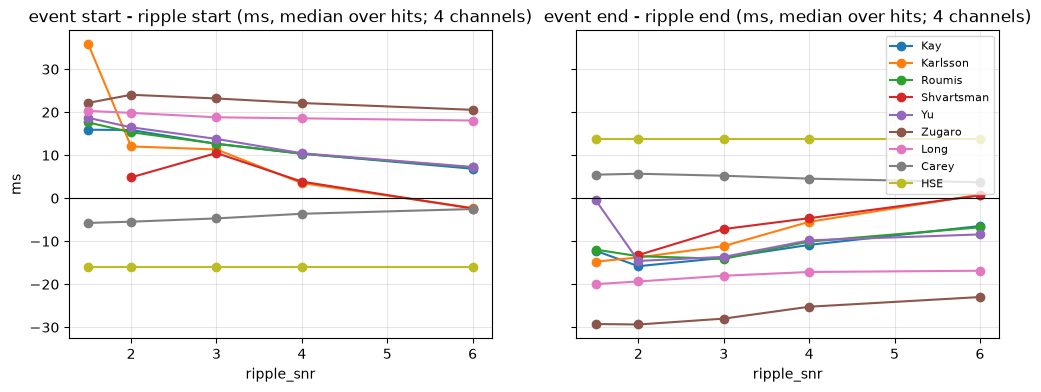

In [4]:
four = ripples[ripples.n_channels == 4]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, metric, title in zip(axes, ["onset_ms", "offset_ms"], ["event start - ripple start", "event end - ripple end"]):
    table = four.pivot_table(index="ripple_snr", columns="detector", values=metric, aggfunc="mean").reindex(columns=ORDER)
    for detector in ORDER:
        ax.plot(table.index, table[detector], marker="o", label=detector)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"{title} (ms, median over hits; 4 channels)")
    ax.set_xlabel("ripple_snr")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("ms")
axes[-1].legend(fontsize=8);

## False positives on ripple-free sessions

In [5]:
noise = results[results.condition == "noise only"]
minutes = 2.0
fp_per_minute = (
    noise.pivot_table(index="detector", columns="n_channels", values="n_events", aggfunc="mean") / minutes
).reindex(ORDER).round(2)
fp_per_minute.columns = [f"{c} ch" for c in fp_per_minute.columns]
fp_per_minute

,1 ch,4 ch,8 ch
detector,,,
Kay,16.50,18.00,17.83
Karlsson,0.67,2.00,4.17
Roumis,16.50,20.67,21.67
Shvartsman,0.00,0.00,0.00
Yu,15.00,13.83,13.00
Zugaro,13.00,10.83,12.17
Long,9.17,7.83,5.50
Carey,1.00,0.67,0.50
HSE,53.33,50.17,50.50


## The spike detectors and the size of the population

In [6]:
dense = results[(results.condition == "ripples") & (results.ripple_snr == 4.0) & (results.n_channels == 4)]
sparse = results[results.condition == "sparse population"]
spike = ["Carey", "HSE"]
comparison = pd.concat(
    {
        "100 units": dense[dense.detector.isin(spike)].groupby("detector")[["recall", "precision", "n_events"]].mean(),
        "20 units": sparse[sparse.detector.isin(spike)].groupby("detector")[["recall", "precision", "n_events"]].mean(),
    },
    axis=1,
).round(2)
comparison

100 units                    20 units                   
            recall precision n_events   recall precision n_events
detector                                                         
Carey         0.98       1.0    39.33     0.74      0.49    61.33
HSE           1.00       0.9    44.33     0.84      0.35    97.33

## Common-mode artifacts

In [7]:
artifacts = results[results.condition == "artifacts"]
clean = results[(results.condition == "ripples") & (results.ripple_snr == 3.0) & (results.n_channels == 4)]
pd.concat(
    {
        "clean (snr 3, 4 ch)": clean.groupby("detector")[["recall", "precision"]].mean(),
        "with 20 artifacts": artifacts.groupby("detector")[["recall", "precision"]].mean(),
    },
    axis=1,
).reindex(ORDER).round(2)

clean (snr 3, 4 ch)           with 20 artifacts          
                        recall precision            recall precision
detector                                                            
Kay                       0.86      0.65              0.03      0.05
Karlsson                  0.66      0.93              0.00      0.00
Roumis                    0.87      0.62              0.03      0.05
Shvartsman                0.32      1.00              0.00      0.00
Yu                        0.76      0.59              0.74      0.39
Zugaro                    0.68      0.78              0.00      0.00
Long                      0.65      0.90              0.58      1.00
Carey                     0.97      1.00              0.92      0.77
HSE                       1.00      0.90              0.98      0.84

### Robust normalization under artifacts

The ripple-band detectors z-score their trace over the whole recording. Twenty artifacts with far more ripple-band power than any ripple inflate that standard deviation until the ripples sit below 2 SD, so recall collapses. `normalization_method="median_mad"` (Kay, Karlsson, Roumis, Shvartsman, HSE) scales by the median absolute deviation, which the artifacts do not inflate; the artifacts are then still detected as events, so precision needs a second step (an amplitude ceiling, or rejecting events present on a reference channel), but the ripples come back. One artifact session, Kay and Karlsson:

In [8]:
fs = 1500.0
time = rd.simulate_time(int(120 * fs), fs)
slots = np.arange(3.0, 118.0, 2.0)
ripple_times = slots[np.arange(slots.size) % 3 != 0]
artifact_times = slots[np.arange(slots.size) % 3 == 0]
session = rd.simulate_session(
    time, list(ripple_times), n_channels=4, n_units=100, ripple_snr=3.0,
    artifact_times=list(artifact_times), random_state=11,
)
filtered = rd.filter_ripple_band(session.lfps, sampling_frequency=fs)

def hit_rates(events):
    windows = session.ripple_windows
    hits = [((events.start_time <= end) & (events.end_time >= start)).any() for start, end in windows]
    matched = np.zeros(len(events), dtype=bool)
    for start, end in windows:
        matched |= ((events.start_time <= end) & (events.end_time >= start)).to_numpy()
    return {"recall": np.mean(hits), "precision": matched.mean() if len(events) else np.nan, "events": len(events)}

rows = {}
for name, detector in [("Kay", rd.Kay_ripple_detector), ("Karlsson", rd.Karlsson_ripple_detector)]:
    for method in ("zscore", "median_mad"):
        events = detector(session.time, filtered, session.speed, fs, normalization_method=method)
        rows[(name, method)] = hit_rates(events)
pd.DataFrame(rows).T.round(2)

recall  precision  events
Kay      zscore        0.03       0.05    21.0
         median_mad    1.00       0.37   105.0
Karlsson zscore        0.00       0.00    20.0
         median_mad    0.66       0.54    48.0

## One session, four detectors

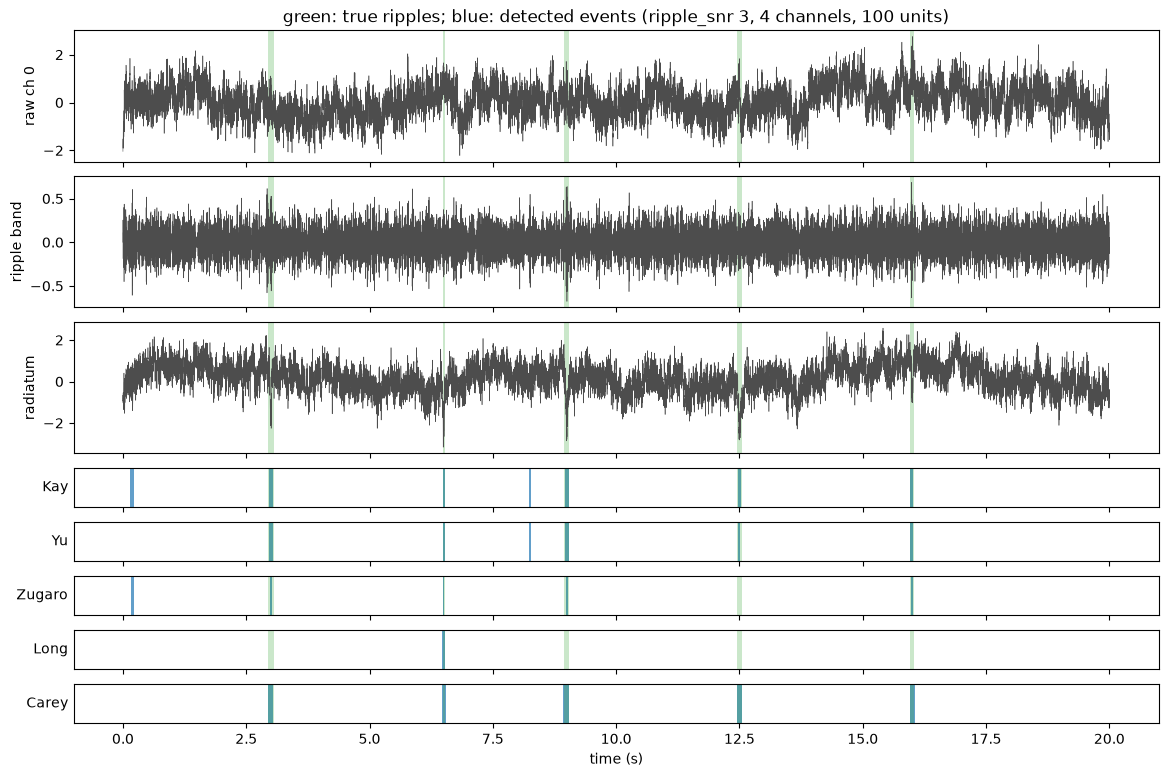

In [9]:
fs = 1500.0
time = rd.simulate_time(int(20 * fs), fs)
session = rd.simulate_session(time, [3.0, 6.5, 9.0, 12.5, 16.0], n_channels=4, n_units=100, ripple_snr=3.0, random_state=7)
filtered = rd.filter_ripple_band(session.lfps, sampling_frequency=fs)
detections = {
    "Kay": rd.Kay_ripple_detector(session.time, filtered, session.speed, fs),
    "Yu": rd.Yu_ripple_detector(session.time, filtered, session.speed, fs),
    "Zugaro": rd.Zugaro_ripple_detector(session.time, filtered, session.speed, fs),
    "Long": rd.Long_sharp_wave_ripple_detector(session.time, session.raw_lfp_pair, session.speed, fs),
    "Carey": rd.Carey_candidate_detector(session.time, filtered, session.multiunit, session.speed, fs),
}
fig, axes = plt.subplots(3 + len(detections), 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [2, 2, 2] + [0.6] * len(detections)})
axes[0].plot(time, session.lfps[:, 0], lw=0.4, color="0.3"); axes[0].set_ylabel("raw ch 0")
axes[1].plot(time, filtered[:, 0], lw=0.4, color="0.3"); axes[1].set_ylabel("ripple band")
axes[2].plot(time, session.raw_lfp_pair[:, 1], lw=0.4, color="0.3"); axes[2].set_ylabel("radiatum")
for ax in axes[:3]:
    for start, end in session.ripple_windows:
        ax.axvspan(start, end, color="tab:green", alpha=0.25, lw=0)
for ax, (name, events) in zip(axes[3:], detections.items()):
    for _, event in events.iterrows():
        ax.axvspan(event.start_time, event.end_time, color="tab:blue", alpha=0.7, lw=0)
    for start, end in session.ripple_windows:
        ax.axvspan(start, end, color="tab:green", alpha=0.25, lw=0)
    ax.set_yticks([]); ax.set_ylabel(name, rotation=0, ha="right", va="center")
axes[-1].set_xlabel("time (s)")
axes[0].set_title("green: true ripples; blue: detected events (ripple_snr 3, 4 channels, 100 units)");

## What this shows

- **The defaults sit at very different operating points.** On ripple-free sessions Kay and Roumis at 2 SD produce about 20 events a minute, Zugaro and Yu 11 to 14, Long 8, Karlsson 2, Carey under 1, Shvartsman none, and the z-scored population rate at 2 SD gives HSE 50. The same thresholds look far better with ripples present because the ripples inflate the standard deviation they are measured against: a threshold in SD units is a threshold on whatever else is in the recording.
- **Karlsson and Shvartsman trade recall for precision.** Each needs one channel (Shvartsman two) to cross 3 SD on its own, so quiet channels (gains between 0.5 and 1 here) cost them ripples below `ripple_snr` 4, and Shvartsman raises on one channel at its default. Their precision is the highest of the ripple-band detectors.
- **Kay, Roumis and Yu pool channels first**, so they reach recall 0.8 by `ripple_snr` 3 with one channel or eight; Kay and Roumis are identical on one channel. Their price is the 2 SD false-positive rate (Kay, Roumis) or a data-driven threshold that falls when channels share noise (Yu, to about 1.1 SD here; `detection_threshold_zscore` reports it).
- **Zugaro's two thresholds** give tighter events (they start about 22 ms after the ripple window and end 25 ms before it) and a false-positive rate between Karlsson's and Kay's.
- **The spike detectors' recall is set by the population burst, not the LFP.** Carey and HSE find 90 to 100 percent of ripples at every `ripple_snr` because the units burst regardless of the ripple's size. Their precision is set by the population: with 20 units instead of 100 it falls from 1.0 to 0.49 (Carey) and from 0.9 to 0.35 (HSE). Carey is also the slowest detector, about 2 s per 120 s of data with 100 units.
- **Long's recall plateaus near 0.9 by construction**: its percentile cuts drop the weakest tenth of the sharp-wave cluster, and it does not evaluate a candidate within 5 s of a block edge. Its events mark the sharp wave (80 ms here), so they start about 20 ms after the ripple window and end 20 ms before it; its precision is high because a ripple without a sharp wave, or a common-mode artifact, does not qualify.
- **Common-mode artifacts silence the ripple-band detectors at their defaults.** Twenty broadband bursts, each with far more ripple-band power than a ripple (about 13 SD on the consensus trace against 2 for the ripples), inflate the z-scoring until the ripples fall below threshold: Kay's recall goes from 0.86 to 0.03. Long cancels them in its channel difference and the spike detectors barely notice them. `normalization_method="median_mad"` brings recall back, to 1.0 for Kay and 0.66 for Karlsson in the session above, and the artifacts are then detected as events, so precision needs a second step: an amplitude ceiling, or rejecting events that also appear on a channel outside the hippocampus.
- **Where events start and end** depends on the rule, not only on the ripple. The envelope-based detectors extend each event to where the trace returns to its mean, which lands 7 to 16 ms inside the window where the envelope is at 1 percent of its peak; the population burst that HSE marks starts 16 ms before it.

## What it cannot show

The simulator's ripples are sinusoids under a Gaussian envelope, its sharp wave a Gaussian deflection, its units Poisson processes that all burst with the same envelope, its noise stationary 1/f with no theta, gamma or state changes, and its artifacts white bursts identical on every channel. These numbers rank the defaults and expose their mechanics; they are not the recall or precision to expect on a recording, and they say nothing about the events a recording contains that the simulator does not produce. To ask a question the sweep does not, change the parameters of `simulate_session` (channel gains, `shared_noise_fraction`, `ripple_duration`, `ripple_frequency`, `n_units`, `participation`, `artifact_amplitude`) or of the detectors in `simulation_study.py` and rerun it.